In [1]:
print("Hello Project")

Hello Project


In [38]:
import pandas as pd
import numpy as np

In [39]:
import pandas as pd

df = pd.read_csv("/content/demand_forecasting.csv")

print(df.head())
print(df.columns)

         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001  Electronics  North              195   
1  2022-01-01     S001      P0002     Clothing  North              117   
2  2022-01-01     S001      P0003     Clothing  North              247   
3  2022-01-01     S001      P0004  Electronics  North              139   
4  2022-01-01     S001      P0005    Groceries  North              152   

   Units Sold  Units Ordered  Price  Discount Weather Condition  Promotion  \
0         102            252  72.72         5             Snowy          0   
1         117            249  80.16        15             Snowy          1   
2         114            612  62.94        10             Snowy          1   
3          45            102  87.63        10             Snowy          0   
4          65            271  54.41         0             Snowy          0   

   Competitor Pricing Seasonality  Epidemic  Demand  
0               85.73      Winte

In [40]:
df['Date'] = pd.to_datetime(df['Date'])

df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.weekday

In [41]:
df = df.dropna()

In [42]:
df = pd.get_dummies(df, columns=[
    'Category','Region','Weather Condition','Seasonality'
], drop_first=True)

In [43]:
df['Effective Price'] = df['Price'] * (1 - df['Discount']/100)
df['Stock Pressure'] = df['Units Ordered'] - df['Inventory Level']

In [44]:
X = df[['Day','Month','Weekday',
        'Inventory Level','Units Ordered',
        'Price','Discount','Promotion',
        'Competitor Pricing','Epidemic']]

y = df['Demand']

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
!pip install xgboost

In [47]:
from xgboost import XGBRegressor

In [48]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [49]:
pred = model.predict(X_test)

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 24.461843490600586
RMSE: 32.36381661634738


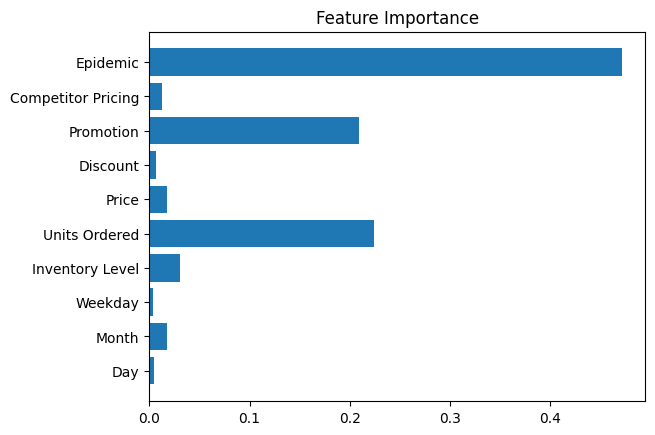

In [51]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [52]:
# Recreate X from SAME df (important)
X_full = df[X.columns]

df['Predicted Demand'] = model.predict(X_full)

In [53]:
df['Suggested Inventory'] = df['Predicted Demand'] + 10

print(df[['Demand','Predicted Demand','Suggested Inventory']].head())

   Demand  Predicted Demand  Suggested Inventory
0     115        116.622147           126.622147
1     229        161.993881           171.993881
2     157        169.636200           179.636200
3      52         96.715233           106.715233
4      59        130.710602           140.710602
